In [1]:
!python3 -m pip install matplotlib google-cloud-bigquery[bqstorage,pandas] pandas pandas-gbq


[notice] A new release of pip is available: 23.3.1 -> 23.3.2
[notice] To update, run: pip install --upgrade pip


In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from google.cloud import bigquery
import pandas as pd

# Bigquery is GCP's managed SQL service
bq_client = bigquery.Client(project="ld-ds-genai-dev")

In [7]:
# First lets pick a store to map, dim_store has all the store location data
store_query = f"""
SELECT hub_store_number, address, city, store_division, store_banner_code
FROM `ds-bi-analytics-prod.bi_dw.dim_store`
WHERE address != "Unknown"
"""
stores_df = pd.read_gbq(store_query, project_id="ld-ds-genai-dev", dialect="standard")
stores_df

,hub_store_number,address,city,store_division,store_banner_code
0,1014,100 McArthur Ave,Ottawa,Market,LOB
1,1188,2210 Bank St,Ottawa,Market,LOB
2,1023,2065A Robertson Rd,Ottawa,Market,LOB
3,1082,1460 Merivale Rd,Ottawa,Market,LOB
4,1132,2085 Carling Ave,Ottawa,Market,LOB
...,...,...,...,...,...
1039,3649,15411 97 St NW,Edmonton,Discount,NF
1040,3967,15411 97 St NW,Edmonton,Discount,NF
1041,3683,6405 92 Ave NW,Edmonton,Discount,NF
1042,3610,366 Main St,Selkirk,Discount,NF


In [8]:
store_id = ""  # Enter any hub_store_number

# This will get the location of all the fixtures (shelves) in the stores
fixture_query  = f"""
WITH
  floor_plan AS (
  SELECT
    DBVERSIONKEY AS floor_plan_key,
    VALUE1 AS store_id,
  FROM
    `ds-bi-analytics-prod.JDA.JDA_IX_FLR_FLOORPLAN`
  WHERE
    VALUE1 = "{store_id}"
    AND DELETED_FLAG = FALSE
    AND STATUS1 = "Live"
    AND DBVERSIONKEY in (select DBPARENTFLOORPLANKEY from `ds-bi-analytics-prod.JDA.JDA_IX_FLR_FIXTURE`)
  ORDER BY
    timestamp DESC
  LIMIT
    1 ),
  fixture AS (
  SELECT
    floor_plan_key,
    store_id,
    SAFE_CAST(ANGLE AS INT64) AS ANGLE,
    SAFE_CAST(WIDTH AS INT64) AS WIDTH,
    SAFE_CAST(DEPTH AS INT64) AS DEPTH,
    SAFE_CAST(HEIGHT AS INT64) AS HEIGHT,
    SAFE_CAST(X AS FLOAT64) AS X,
    SAFE_CAST(Y AS FLOAT64) AS Y,
    SAFE_CAST(Z AS FLOAT64) AS Z,
    DESC5 AS AISLE,
    DESC9 AS PCX_LOCATION,
    TYPE AS FIXTURE_TYPE,
  FROM
    floor_plan
  LEFT JOIN
    `ds-bi-analytics-prod.JDA.JDA_IX_FLR_FIXTURE` fixt
  ON
    fixt.DBPARENTFLOORPLANKEY = floor_plan.floor_plan_key
  WHERE
    DELETED_FLAG = FALSE
  AND
    TYPE in ("0", "1")) -- type 0 is for regular fixtures, and type 1 for irregular ones

SELECT
  floor_plan_key,
  store_id,
  X AS STARTING_X,
  case
    when fixture.ANGLE in (270,90) then COS(-1*fixture.Angle*0.01745329251)*fixture.WIDTH + SIN(-1*fixture.Angle*0.01745329251)*fixture.DEPTH +fixture.X
    else COS(fixture.Angle*0.01745329251)*fixture.WIDTH + SIN(fixture.Angle*0.01745329251)*fixture.DEPTH + fixture.X
  end AS ENDING_X,
  Y AS STARTING_Y,
  (SIN(fixture.Angle*0.01745329251)*fixture.WIDTH + COS(fixture.Angle*0.01745329251)*fixture.DEPTH + fixture.Y) AS ENDING_Y,
  Z,
  WIDTH,
  DEPTH,
  HEIGHT,
  ANGLE,
  AISLE,
  PCX_LOCATION,
  FIXTURE_TYPE,
FROM
  fixture
"""
fixtures_df = pd.read_gbq(fixture_query, project_id="ld-ds-genai-dev", dialect="standard")

fixtures_df

,floor_plan_key,store_id,STARTING_X,ENDING_X,STARTING_Y,ENDING_Y,Z,WIDTH,DEPTH,HEIGHT,ANGLE,AISLE,PCX_LOCATION,FIXTURE_TYPE
0,208376,1011,592.863276,580.863276,1669.155640,1717.155640,0.2,48,12,2,90,DL01L,None,0
1,208376,1011,2239.796289,2227.796289,1981.488159,2029.488159,0.2,48,12,2,90,JO01C,None,0
2,208376,1011,568.863276,580.863276,1669.155640,1621.155640,0.2,48,12,2,270,DL01L,None,0
3,208376,1011,592.863276,580.863276,2077.405762,2125.405762,0.2,48,12,2,90,DL01L,None,0
4,208376,1011,2189.842344,2177.842344,1692.227812,1740.227813,0.2,48,12,2,90,JO01C,None,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1608,208376,1011,2818.020020,2787.020020,1812.650391,1860.650391,0.2,48,31,2,90,GR03L,None,0
1609,208376,1011,2818.020020,2787.020020,1956.650391,2004.650391,0.2,48,31,2,90,GR03L,None,0
1610,208376,1011,3114.130029,3084.130029,2216.428412,2312.428412,0.2,96,30,2,90,GR05L,None,0
1611,208376,1011,3114.130029,3084.130029,1928.428412,2024.428412,0.2,96,30,2,90,GR05L,None,0


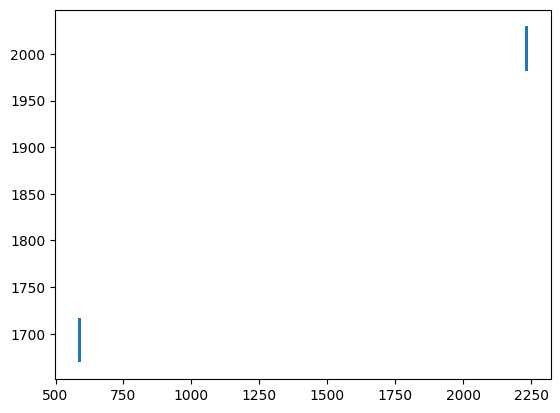

In [12]:
# This plots 2 fixtures, modify the code to plot all of them
fig, ax = plt.subplots()
ax.plot()

x = fixtures_df["STARTING_X"][0]
y = fixtures_df["STARTING_Y"][0]
x1 = fixtures_df["ENDING_X"][0]
y1 = fixtures_df["ENDING_Y"][0]
ax.add_patch(Rectangle((x, y), float(x1-x), float(y1-y)))

x = fixtures_df["STARTING_X"][1]
y = fixtures_df["STARTING_Y"][1]
x1 = fixtures_df["ENDING_X"][1]
y1 = fixtures_df["ENDING_Y"][1]
ax.add_patch(Rectangle((x, y), float(x1-x), float(y1-y)))

plt.show()

In [10]:
# Now lets put some items on those shelves
# This query will get the product's ID (liam) and location in the store you chose
# NOTE: This doesn't contain all products, it is missing fresh products nad meat
item_fixture_query  = f"""
SELECT
  liam,
  name_en,
  nav_categories_en,
  STARTING_X_FT*12 AS X1,
  STARTING_Y_FT*12 AS Y1
FROM
  `ds-bi-analytics-prod.JDA.JDA_ITEM_LOCATION` jda
JOIN (
  SELECT
    liam, name_en, STRING_AGG(cat.en, ", ") AS nav_categories_en
  FROM
    `ds-bi-analytics-prod.product_catalog.products`
  LEFT JOIN
    UNNEST(nav_categories) AS cat
  WHERE
    status="APPROVED"
  GROUP BY liam, name_en)pcs
ON
  jda.ARTICLE_ID_UOM = pcs.liam
WHERE
  STORE_ID = "{store_id}"
"""
item_fixtures_df = pd.read_gbq(item_fixture_query, project_id="ld-ds-genai-dev", dialect="standard")
item_fixtures_df = item_fixtures_df[item_fixtures_df["nav_categories_en"].notna()].reset_index(drop=True)
item_fixtures_df["nav_categories_en"] = item_fixtures_df["nav_categories_en"].str.lower()
item_fixtures_df["nav_categories_en"] = item_fixtures_df["nav_categories_en"].str.split(", ")

item_fixtures_df

,liam,name_en,nav_categories_en,X1,Y1
0,21386358_C08,Tonic Water Light,"[food, natural and organic, drinks, carbonated...",2052.720000000,2145.240000000
1,20022239_EA,"Tofu, Medium Firm","[food, international foods, east asian foods, ...",417.600000000,1774.680000000
2,20169654_EA,Parsley,"[food, pantry, spices & seasonings]",3721.680000000,1452.120000000
3,21024592_EA,Anchovies,"[food, fish & seafood, fish]",1755.720000000,3070.200000000
4,20792242_EA,Cooked Shrimp 61-70 ct,"[food, international foods, east asian foods, ...",1554.240000000,2946.480000000
...,...,...,...,...,...
31213,21344479_EA,Samosa Jalapeño & Cheese,"[food, international foods, south asian foods,...",4210.800000000,1989.000000000
31214,21406553_EA,"Potatoes, Sour Cream & Chives Perogies","[food, frozen, meals, entrees & sides, pasta &...",4210.800000000,1899.000000000
31215,20301001_EA,Vegetable Lasagna,"[food, frozen, meals, entrees & sides, meals]",4210.800000000,1869.000000000
31216,20318616003_EA,"Gourmet Steamers, Pineapple Chicken","[food, frozen, meals, entrees & sides, meals]",4210.800000000,1869.000000000


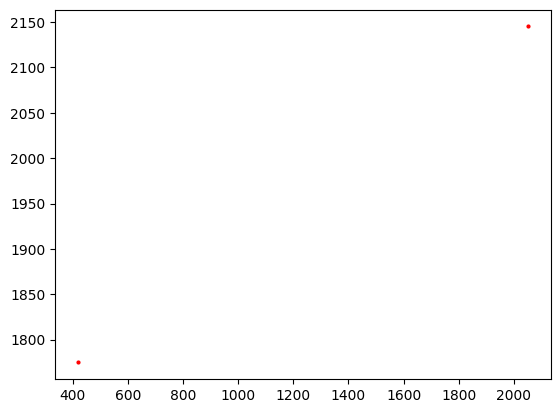

In [14]:
# This plots 2 products, modify the code to plot all of them along with the fixtures
fig, ax = plt.subplots()
ax.plot()

x = item_fixtures_df["X1"][0]
y = item_fixtures_df["Y1"][0]
plt.plot(x, y, 'o', markersize=2, color='#ff0000')

x = item_fixtures_df["X1"][1]
y = item_fixtures_df["Y1"][1]
plt.plot(x, y, 'o', markersize=2, color='#ff0000')

plt.show()

In [34]:
# We also included the category info in that table, lets see which categories there are and how many products are in them
level_2_categories = item_fixtures_df["nav_categories_en"].apply(lambda x: x[1]).value_counts()
level_2_categories

nav_categories_en
pantry                                 4871
personal care                          3907
natural and organic                    2722
snacks                                 2064
drinks                                 2040
                                       ... 
electrical supplies                       2
home & kitchen                            2
fasteners                                 1
scrapbooking                              1
painting supplies & wall treatments       1
Name: count, Length: 71, dtype: int64

In [15]:
# Here are all frozen items, try plotting all items with different colors based on their second level category
item_fixtures_subset = item_fixtures_df[item_fixtures_df["nav_categories_en"].apply(lambda x: x[1] == "frozen")]
item_fixtures_subset

,liam,name_en,nav_categories_en,X1,Y1
35,21479266_EA,Smoky Bacon Crab Flavoured Dip,"[food, frozen, frozen meat & seafood, frozen f...",1755.720000000,3070.200000000
53,21529587_EA,Quick-N-Easy Beef & Pork Meatloaf With Barbequ...,"[food, frozen, meals, entrees & sides, meals]",3034.920000000,3068.280000000
65,21332404_EA,Organics Peeled Raw Black Tiger Shrimp,"[food, frozen, frozen meat & seafood, frozen f...",1465.440000000,2874.480000000
107,20078077_EA,Roast Beef au Jus,"[food, frozen, meals, entrees & sides, meals]",3034.920000000,3068.280000000
112,20184093_EA,Zipperback Colossal Raw Freshwater Shrimp,"[food, frozen, frozen meat & seafood, frozen f...",1465.440000000,2874.480000000
...,...,...,...,...,...
31212,21022094_EA,"Valley Selection, Asian Blend Vegetables","[food, frozen, frozen fruit & vegetables, froz...",4210.800000000,2319.000000000
31214,21406553_EA,"Potatoes, Sour Cream & Chives Perogies","[food, frozen, meals, entrees & sides, pasta &...",4210.800000000,1899.000000000
31215,20301001_EA,Vegetable Lasagna,"[food, frozen, meals, entrees & sides, meals]",4210.800000000,1869.000000000
31216,20318616003_EA,"Gourmet Steamers, Pineapple Chicken","[food, frozen, meals, entrees & sides, meals]",4210.800000000,1869.000000000


In [9]:
# Lets dive into the product metadata contained within PCS
pcs_query = """
SELECT
    pcs.article_number AS product_article_number,
    liam AS product_id,
    TRIM(brand.name_en) AS brand_en,
    TRIM(brand.sub_brand.name_en) AS sub_brand_en,
    TRIM(name_en) AS title_en,
    TRIM(REGEXP_REPLACE(description_en, r'(<\/?[a-z]+>)+', '')) AS description_en,
    STRING_AGG(cat.en, ", ") AS nav_categories_en
FROM
    `ds-bi-analytics-prod.product_catalog.products` pcs
LEFT JOIN
    UNNEST(nav_categories) AS cat
WHERE
    status = 'APPROVED'
    AND NOT SUBSTRING(liam, 0, 2) = 'DD'
GROUP BY
    pcs.article_number,
    liam,
    name_en,
    description_en,
    brand.name_en,
    brand.sub_brand.name_en
"""
pcs_df = pd.read_gbq(pcs_query, project_id="ld-ds-genai-dev", dialect="standard")
pcs_df

,product_article_number,product_id,brand_en,sub_brand_en,title_en,description_en,nav_categories_en
0,20557414001,20557414001_EA,Amira,None,Meli Melo,None,"Food, Pantry, Bulk Nuts and Candy"
1,21384506002,21384506002_EA,Essence,None,Brow Pencil Dark Brunette,None,"Health & Beauty, Beauty Products, Cosmetics, E..."
2,062600267306,SDM_062600267306,Aveeno,None,Baby Wipes for Sensitive Skin,New Aveeno Baby Hand and Face Wipes for baby’s...,"Baby & Child, Baby & Child Care, Diapers & Wip..."
3,094100007809,SDM_094100007809,OPI,None,Nail Lacquer,Share brunch-y cocktails over this simple pink...,"Beauty, Makeup, Nails, Nail Colour"
4,3401399373756,SDM_3401399373756,Bioderma,None,Atoderm Lip Balm,"Daily, moisturizing lip balm that visibly rest...","Beauty, Makeup, Lips, Lip Balm & Treatment"
...,...,...,...,...,...,...,...
427007,20710699,20710699_EA,Everyday Essentials,None,Round Dinner Plates,None,"Home & Kitchen, Dining & Entertaining, Disposa..."
427008,20710700,20710700_EA,Everyday Essentials,None,"2 Ply Buffet Napkin, 2 Colour",None,"Household Supplies, Bathroom Tissue & Paper Pr..."
427009,21345073,21345073_EA,Everyday Essentials,None,"Scented Candle, Apple Pie",Bring the aromas of fall baking into your home...,"Home & Kitchen, Home Decor, Candles & Home Fra..."
427010,21285528,21285528_EA,Everyday Essentials,None,Stainless Steel 2-Pack Cookie Cutter,None,"Home & Kitchen, Kitchen, Kitchen Utensils, Gad..."


In [40]:
# Some products are missing brand, descriptions, categories
display(pcs_df[pcs_df["brand_en"].isna()])
display(pcs_df[pcs_df["title_en"].isna()])
display(pcs_df[pcs_df["description_en"].isna()])
display(pcs_df[pcs_df["nav_categories_en"].isna()])

,product_article_number,product_id,brand_en,sub_brand_en,title_en,description_en,nav_categories_en
608,20162728001,20162728001_EA,None,None,Baking Potatoes,Baking (or russet) potatoes have a rough brown...,None
837,3264680005374,SDM_3264680005374,None,None,Crème Fraichede Beauté Masque\n24hr Soothing a...,A source of well-being and immediate freshness...,None
1129,20545752,20545752_EA,None,None,Wind Resistant BBQ lighter,None,None
1151,20060060,20060060_EA,None,None,Atemoya,Atemoya is a fruit with bumpy green skin and c...,None
1178,20381176,20381176_EA,None,None,Black Label Équateur Origine Dark Chocolate Co...,"With 72% cocoa, our bold dark chocolate couver...",None
...,...,...,...,...,...,...,...
214573,20319740002,20319740002_C12,None,None,Lactose Free A+ Concentrated Formula (Case),None,None
214643,3349668600298,SDM_3349668600298,None,None,1 Million Elixir Parfum Intense,Paco Rabanne 1 Million Elixir: the pinnacle of...,"Beauty, Men's, Fragrance for Him, Cologne, Bea..."
214717,20628759001,20628759001_EA,None,None,"Cereal, Rice & Baa",None,None
214805,20300190,20300190_KG,None,None,"Lean Ground Beef, Tray Pack",None,None


,product_article_number,product_id,brand_en,sub_brand_en,title_en,description_en,nav_categories_en
32379,BB,SDM_BB_5060663680112,None,None,None,None,None
73232,BB,SDM_BB_5060663680099,None,None,None,None,None


,product_article_number,product_id,brand_en,sub_brand_en,title_en,description_en,nav_categories_en
0,20594766002,20594766002_EA,Nong Shim,BOWL NOODLE,"Bowl Noodle Soup, Beef Flavour",None,"Food, Pantry, Easy Meals & Sides, Dry Soup Mix..."
3,20376950,20376950_EA,ACADIAN MAPLE,None,Acadian Maple Products Nova Scotia Wild Bluebe...,None,"Food, Pantry, Honey, Syrups & Spreads, Maple S..."
4,20974246,20974246_EA,Unique,None,9oz Finding Dory Cups,None,"Toys, Games & Party Supplies, Party Supplies, ..."
9,884392597542,SDM_884392597542,Safety 1St,None,Grow With Me Medicine Set,None,"Baby & Child, Baby & Child Care, Childproofing..."
10,21185534,21185534_EA,Voortman,None,Mango Wafer Cookies,None,"Food, Snacks, Chips & Candy, Crackers & Cookie..."
...,...,...,...,...,...,...,...
427090,20839688,20839688_EA,Everyday Essentials,None,"Microfibre Drying Mat, Printed",None,"Home & Kitchen, Dining & Entertaining, Table L..."
427093,20869142,20869142_EA,Everyday Essentials,None,"Round Tin, Large",None,"Home & Kitchen, Dining & Entertaining, Servewa..."
427095,20754583,20754583_EA,Everyday Essentials,None,"Plastic Glide Hooks, White",None,"Home & Kitchen, Bath, Bathtub & Shower Accesso..."
427096,20867000,20867000_EA,Everyday Essentials,None,Owl Creamer & Sugar Holders,None,"Home & Kitchen, Dining & Entertaining, Servewa..."


,product_article_number,product_id,brand_en,sub_brand_en,title_en,description_en,nav_categories_en
12,3380814024513,SDM_3380814024513,Clarins,None,Everlasting Compact Foundation SPF 15,A high-performance foundation with an ultra-fi...,None
18,8411061962015,SDM_8411061962015,Carolina Herrera,None,Good Girl Glorious Gold Holiday Collector Eau ...,Good Girl Glorious Gold Holiday Collector Eau ...,None
25,21029278,21029278_EA,Papermate,FLAIR,"Flair! Felt Tip Pens, Limited Edition Candy Pop",None,None
63,21204508,21204508_C18,Reese's,None,Outrageous Candy,None,None
68,4020829078895,SDM_4020829078895,Dr.Hauschka,None,Dr H Starter Kit Cmbntion Skin,Discover Dr. Hauschka three-step skin care rit...,None
...,...,...,...,...,...,...,...
426935,20725817,20725817_EA,Everyday Essentials,None,"Clear Accessories Box, 2L",Includes snap-on lidStackableWipe with damp cloth,None
426956,21398035,21398035_EA,Everyday Essentials,None,15 Paper Cups - Summer Geo,350ml,None
426960,20759028,20759028_EA,Everyday Essentials,None,"Locker Storage, Large",None,None
427041,21414130,21414130_EA,Everyday Essentials,None,15 Paper Cups Flower,350ml,None


#### Some products that are missing descriptions have other metadata, lets use that along with ChatGPT to generate some product descriptions
#### Try out Garfielld using data from some of these products and put together a prompt which creates a description like our other products

https://garfielld.loblaw.ca/